# Mejora 9 - Robustez: aumento de datos y última oración con opinión

**Proyecto - Parte 1: Machine Learning clásico**

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

La primera versión del notebook `Diagnostico_Modelo_Final.ipynb` encontró la principal debilidad del modelo elegido (dos etapas + NB-LR, Mejora 7): basta con agregar una frase sin opinión al final de una reseña, como "Viene en color negro.", para que su exactitud caiga de 0,90 a entre 0,63 y 0,71. Los modelos aprendieron que la última oración decide la etiqueta, y lo aplican aunque esa oración no tenga ninguna opinión. En la competencia no es un problema, porque las reseñas de `eval.csv` tienen la misma estructura que las de entrenamiento, pero sí lo sería con reseñas reales, que con frecuencia terminan con comentarios sin opinión.

Este notebook prueba dos arreglos clásicos para esa debilidad:

- **A. Aumento de datos:** agregar oraciones neutras al final de la mitad de las reseñas de entrenamiento, sin cambiar su etiqueta, para que el modelo aprenda que la última oración no siempre decide.
- **B. Última oración con opinión:** en lugar de la última oración, usar la última oración que tiene una opinión, según un detector entrenado para distinguir "opinión" de "hecho".

Los dos arreglos se aplican a la regresión logística por bloques y al modelo de la Mejora 7. Se evalúa la exactitud normal, que es lo que mide la competencia, y la robustez: la exactitud cuando se agrega una frase neutra al final.

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. Todo se basa en TF-IDF, n-gramas y modelos lineales. |
| Usar únicamente modelos de scikit-learn. | Los modelos son `LogisticRegression` y `MultinomialNB`. `ExtraerConOpinion` y `ConAumento` solo preparan los datos con la interfaz de scikit-learn. |
| Usar solo `train.csv` para entrenar. | El aumento de datos y el detector se construyen solo con oraciones de `train.csv`. |
| Resultados replicables. | Semillas fijas, versiones en `requirements.txt` y todo el flujo en este notebook (sección 11). |

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Datos y partición

Se usa la misma partición 80/20 estratificada (semilla 42) de los notebooks anteriores. El conjunto de prueba se usa para medir exactitud y robustez en la sección 6, y la comparación de 15 particiones (sección 7) usa las mismas particiones que las Mejoras 4 y 7.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))
X = train[['text']]
y = train['label']

# Misma partición que los notebooks anteriores
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('train:', train.shape, '| eval:', evaluacion.shape, '| entrenamiento:', X_train.shape, '| prueba:', X_test.shape)

train: (12000, 3) | eval: (3000, 2) | entrenamiento: (9600, 1) | prueba: (2400, 1)


## 3. Código de la Mejora 7

Se copian sin cambios el preprocesamiento, la corrección de la cláusula final, NB-LR y la clase `ModeloDosEtapasNBLR` del notebook de la Mejora 7.

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques del notebook principal, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    """Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    """

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

In [6]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    """Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector."""
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]

In [7]:
class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    """Modelo en dos etapas de la Mejora 1 al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    """

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

## 4. El problema: una frase neutra al final

Primero se reproduce el problema en el conjunto de prueba. Cada reseña se predice tal cual y con una frase neutra agregada al final: las mismas cuatro frases del diagnóstico y, además, una oración tomada de una reseña neutral del propio conjunto de prueba, que el modelo nunca vio. Ninguno de estos cambios debería modificar la etiqueta.

In [8]:
FRASES_NEUTRAS = ['Lo uso casi todos los días en la oficina.', 'El paquete llegó en una caja de cartón.',
                  'Lo compré por internet hace un mes.', 'Viene en color negro.']


def versiones_con_frase(textos, etiquetas, semilla=0):
    """El texto original, el texto con cada frase neutra al final y el texto con una oración de una reseña neutral
    del mismo conjunto (que el modelo no vio al entrenarse) al final."""
    textos, etiquetas = list(textos), np.asarray(etiquetas)
    rng = np.random.default_rng(semilla)
    banco = [o for t, e in zip(textos, etiquetas) if e == 'neutral' for o in separar_oraciones(t) if len(o.split()) >= 4]
    versiones = {'original': textos}
    for i, frase in enumerate(FRASES_NEUTRAS):
        versiones[f'+ "{frase}"'] = [t.rstrip() + ' ' + frase for t in textos]
    versiones['+ oración de una reseña neutral'] = [t.rstrip() + ' ' + banco[rng.integers(len(banco))] for t in textos]
    return versiones


def exactitud_por_version(modelo, versiones, etiquetas):
    return {v: accuracy_score(etiquetas, modelo.predict(pd.DataFrame({'text': textos}))) for v, textos in versiones.items()}


versiones_test = versiones_con_frase(X_test['text'], y_test)
modelo_m7 = ModeloDosEtapasNBLR(C_etapa2=0.1).fit(X_train, y_train)
modelo_lr = Pipeline([('rep', construir_representacion_corregida()),
                      ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                    random_state=RANDOM_STATE))]).fit(X_train, y_train)
antes = pd.DataFrame({'Mejora 7': exactitud_por_version(modelo_m7, versiones_test, y_test),
                      'Regresión logística corregida': exactitud_por_version(modelo_lr, versiones_test, y_test)})
antes.round(4)

,Mejora 7,Regresión logística corregida
original,0.8988,0.8954
"+ ""Lo uso casi todos los días en la oficina.""",0.6708,0.6821
"+ ""El paquete llegó en una caja de cartón.""",0.6683,0.5400
"+ ""Lo compré por internet hace un mes.""",0.6983,0.6717
"+ ""Viene en color negro.""",0.6150,0.4929
+ oración de una reseña neutral,0.6525,0.6033


El problema se reproduce en los dos modelos:

- **Mejora 7:** pasa de 0,8988 a entre 0,6150 y 0,6983, una caída de 20 a 28 puntos.
- **Regresión logística corregida:** pasa de 0,8954 a entre 0,4929 y 0,6821, una caída de 21 a 40 puntos. La peor frase es "Viene en color negro.".

La última fila es la más importante. Con una oración tomada de una reseña neutral real, que ninguno de los dos modelos vio al entrenarse, la caída es igual de grande (0,6525 y 0,6033). Es decir, el problema no depende de las cuatro frases que elegimos.

## 5. Los dos arreglos

### 5.1 Arreglo A: aumento de datos con frases neutras

A la mitad de las reseñas de entrenamiento, elegidas al azar, se les agrega al final una oración tomada de una reseña neutral del mismo conjunto de entrenamiento, sin cambiar su etiqueta. Se modifican esas reseñas en lugar de duplicarlas: si se agregaran copias, la validación cruzada interna del modelo en dos etapas vería casi la misma reseña en entrenamiento y en validación.

La clase `ConAumento` envuelve a cualquier modelo y aplica el aumento solo al entrenarlo. Así se puede usar con `cross_val_score` sin que las reseñas modificadas lleguen a la validación.

In [9]:
def aumentar(textos, etiquetas, proporcion=0.5, semilla=0):
    """Agrega al final de una proporción de las reseñas una oración tomada de reseñas neutrales (sin cambiar la etiqueta)."""
    rng = np.random.default_rng(semilla)
    banco = [o for t, e in zip(textos, etiquetas) if e == 'neutral' for o in separar_oraciones(t) if len(o.split()) >= 4]
    return [t.rstrip() + ' ' + banco[rng.integers(len(banco))] if rng.random() < proporcion else t for t in textos]


class ConAumento(ClassifierMixin, BaseEstimator):
    """Entrena el modelo con el arreglo A aplicado solo a los datos de entrenamiento. Al predecir no cambia nada."""

    def __init__(self, modelo, proporcion=0.5, random_state=0):
        self.modelo = modelo
        self.proporcion = proporcion
        self.random_state = random_state

    def fit(self, X, y):
        textos = aumentar(list(X['text']), np.asarray(y), self.proporcion, self.random_state)
        self.modelo_ = clone(self.modelo).fit(pd.DataFrame({'text': textos}), np.asarray(y))
        self.classes_ = self.modelo_.classes_
        return self

    def predict_proba(self, X):
        return self.modelo_.predict_proba(X)

    def predict(self, X):
        return self.modelo_.predict(X)


ejemplo_aumentado = aumentar(list(X_train['text']), y_train.values, proporcion=1.0, semilla=3)[0]
print('ORIGINAL:\n', X_train['text'].iloc[0])
print('\nCON UNA ORACIÓN NEUTRA AL FINAL:\n', ejemplo_aumentado)

ORIGINAL:
 Lo compré hace un par de meses por internet y llegó en tres días. Desde que llegó lo uso para el gimnasio. La carga se hace con un conector magnético por un puerto propio. Por cierto, trae garantía de un año.

CON UNA ORACIÓN NEUTRA AL FINAL:
 Lo compré hace un par de meses por internet y llegó en tres días. Desde que llegó lo uso para el gimnasio. La carga se hace con un conector magnético por un puerto propio. Por cierto, trae garantía de un año. Me llegó en dos días.


### 5.2 Arreglo B: la última oración con opinión

El arreglo B cambia qué oración se usa en los bloques "última oración" y "cláusula final". Un detector decide qué oraciones tienen una opinión, y se usa la última que la tenga.

El detector es una regresión logística sobre TF-IDF que distingue **opinión** de **hecho**, entrenada con dos tipos de ejemplos:

- **Hecho:** todas las oraciones de las reseñas neutrales, que describen características sin opinar.
- **Opinión:** la cláusula final de cada reseña positiva o negativa, que casi siempre contiene la opinión que define la etiqueta.

Hay dos cuidados importantes:

- El detector se entrena solo con `train.csv`, y dentro de la validación cruzada solo con las reseñas de entrenamiento de cada partición.
- Para las oraciones de entrenamiento se usa la probabilidad calculada fuera de muestra. Si no, el detector reconocería de memoria las cláusulas finales con que se entrenó y las marcaría siempre como opinión.

La clase `ExtraerConOpinion` reemplaza a la extracción de la última oración y de la cláusula final en la regresión logística y en los modelos por bloques del modelo en dos etapas (`ModeloDosEtapasNBLROpinion`). El resto del modelo de la Mejora 7 no cambia.

In [10]:
class ExtraerConOpinion(BaseEstimator, TransformerMixin):
    """Devuelve, limpia, la última oración con opinión de cada reseña (o su cláusula final).

    Un detector distingue "opinión" de "hecho": una regresión logística sobre TF-IDF entrenada con las oraciones de
    reseñas neutrales (hecho) y con la cláusula final de las reseñas positivas o negativas (casi siempre una opinión).
    Una oración tiene opinión si P(opinión) > umbral. Si ninguna la tiene, se usa la última oración.
    Para las oraciones de entrenamiento se usa la probabilidad fuera de muestra (validación cruzada agrupada por
    reseña); si no, el detector las reconocería de memoria.
    """

    def __init__(self, parte='ultima', umbral=0.5, stemming=True):
        self.parte = parte
        self.umbral = umbral
        self.stemming = stemming

    def fit(self, X, y):
        textos, y = list(np.asarray(X)), np.asarray(y)
        frases, etiquetas, grupo = [], [], []
        for i, (t, e) in enumerate(zip(textos, y)):
            if e == 'neutral':
                for o in separar_oraciones(t):
                    frases.append(limpiar_texto(o)); etiquetas.append(0); grupo.append(i)
            else:
                frases.append(limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]))); etiquetas.append(1); grupo.append(i)
        frases, etiquetas, grupo = np.array(frases, dtype=object), np.array(etiquetas), np.array(grupo)
        self.fuera_de_muestra_ = {}
        for a, b in GroupKFold(n_splits=5).split(frases, etiquetas, grupo):
            vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
            m = LogisticRegression(C=1, max_iter=2000).fit(vec.fit_transform(frases[a]), etiquetas[a])
            for o, p in zip(frases[b], m.predict_proba(vec.transform(frases[b]))[:, 1]):
                self.fuera_de_muestra_[o] = p
        self.vectorizador_ = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
        self.detector_ = LogisticRegression(C=1, max_iter=2000).fit(self.vectorizador_.fit_transform(frases), etiquetas)
        return self

    def prob_opinion(self, oraciones_limpias):
        faltan = [o for o in oraciones_limpias if o not in self.fuera_de_muestra_]
        nuevas = dict(zip(faltan, self.detector_.predict_proba(self.vectorizador_.transform(faltan))[:, 1])) if faltan else {}
        return np.array([self.fuera_de_muestra_.get(o, nuevas.get(o)) for o in oraciones_limpias])

    def oracion_con_opinion(self, texto):
        oraciones = separar_oraciones(texto)
        p = self.prob_opinion([limpiar_texto(o) for o in oraciones])
        con_opinion = np.where(p > self.umbral)[0]
        return oraciones[con_opinion[-1]] if len(con_opinion) else oraciones[-1]

    def transform(self, X):
        salida = []
        for t in np.asarray(X):
            o = self.oracion_con_opinion(t)
            if self.parte == 'clausula':
                o = ultimo_fragmento(o)
            salida.append(limpiar_texto(o, stemming=self.stemming))
        return salida


def construir_representacion_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
    ])


def construir_bolsas_binarias_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
    ])


class ModeloDosEtapasNBLROpinion(ModeloDosEtapasNBLR):
    """Mejora 7 con los bloques de última oración y cláusula final tomados de la última oración con opinión."""

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_opinion().fit(datos, etiquetas)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias_opinion()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

In [11]:
detector = ExtraerConOpinion('ultima').fit(X_train['text'], y_train)
ultima = [separar_oraciones(t)[-1] for t in X_test['text']]
es_polar = (y_test != 'neutral').values

elegida = [detector.oracion_con_opinion(t) for t in X_test['text']]
print(f'Sin cambios en el texto, el detector elige una oración distinta de la última en '
      f'{np.mean([e != u for e, u in zip(elegida, ultima)]):.1%} de las reseñas de prueba')
for version in list(versiones_test)[1:]:
    elegida = [detector.oracion_con_opinion(t) for t in versiones_test[version]]
    print(f'{version:48s} -> en reseñas positivas/negativas elige la última oración original en '
          f'{np.mean([e == u for e, u, p in zip(elegida, ultima, es_polar) if p]):.1%}')

print('\nEjemplos de reseñas cuya última oración no tiene opinión:')
for t in [t for t in X_test['text'] if detector.oracion_con_opinion(t) != separar_oraciones(t)[-1]][:3]:
    oraciones = separar_oraciones(t)
    p = detector.prob_opinion([limpiar_texto(o) for o in oraciones])
    for o, pi in zip(oraciones, p):
        print(f'   P(opinión) = {pi:.2f} | {o}')
    print(f'   -> elegida: {detector.oracion_con_opinion(t)}\n')

Sin cambios en el texto, el detector elige una oración distinta de la última en 4.0% de las reseñas de prueba


+ "Lo uso casi todos los días en la oficina."    -> en reseñas positivas/negativas elige la última oración original en 94.5%


+ "El paquete llegó en una caja de cartón."      -> en reseñas positivas/negativas elige la última oración original en 94.5%


+ "Lo compré por internet hace un mes."          -> en reseñas positivas/negativas elige la última oración original en 94.5%


+ "Viene en color negro."                        -> en reseñas positivas/negativas elige la última oración original en 94.5%


+ oración de una reseña neutral                  -> en reseñas positivas/negativas elige la última oración original en 93.9%

Ejemplos de reseñas cuya última oración no tiene opinión:


   P(opinión) = 0.01 | Lo compré hace como tres semanas porque lo vi de pasada y me lo mandaron a casa en cuatro días.
   P(opinión) = 0.02 | Usa tres pilas AAA, así que antes de usarlo por primera vez tuve que salir a comprarlas porque no venían incluidas.
   P(opinión) = 0.86 | El empaque está por encima de la media, se nota el cuidado.
   P(opinión) = 0.17 | Lo tengo en la mesita de noche y ahí sigue funcionando.
   -> elegida: El empaque está por encima de la media, se nota el cuidado.

   P(opinión) = 0.04 | Lo compré a mediados de agosto para ver las series por las noches.
   P(opinión) = 0.91 | La nitidez de la imagen me dio más de un dolor de cabeza.
   P(opinión) = 0.14 | Lo conecté por HDMI al televisor del cuarto y probé varias configuraciones sin que cambiara nada.
   -> elegida: La nitidez de la imagen me dio más de un dolor de cabeza.

   P(opinión) = 0.01 | Lo compre hace un par de mess para usarlo en la casa, mas que nada en las tards despues del trabajo.
   P(opinión) 

El detector se comporta como se esperaba:

- **Con las reseñas originales casi no cambia nada:** elige una oración distinta de la última solo en el 4,0% de las reseñas de prueba. En el resto, la última oración ya tiene opinión.
- **Con una frase neutra al final la salta:** en las reseñas positivas y negativas vuelve a elegir la última oración original en el 94,5% de los casos con las cuatro frases, y en el 93,9% con oraciones de reseñas neutrales.
- **En los ejemplos** descarta oraciones que describen la compra, el envío o el producto (probabilidad de opinión entre 0,01 y 0,04) y elige la que contiene la opinión.

El detector tiene un límite. Solo reconoce opiniones explícitas: "Lo he tenido que apagar y prender varias veces en una misma semana." es una queja implícita, pero el detector le da 0,17 y la trata como un hecho. En ese ejemplo no hace daño, porque la oración elegida también es negativa, pero en otras reseñas podría saltar la oración que decide la etiqueta.

## 6. Evaluación en el conjunto de prueba: exactitud y robustez

,Regresión logística corregida,Regresión logística + A + B,Mejora 7,Mejora 7 + A + B
original,0.8954,0.9033,0.8988,0.9025
"+ ""Lo uso casi todos los días en la oficina.""",0.6821,0.9021,0.6708,0.9033
"+ ""El paquete llegó en una caja de cartón.""",0.5400,0.9025,0.6683,0.9067
"+ ""Lo compré por internet hace un mes.""",0.6717,0.9012,0.6983,0.9054
"+ ""Viene en color negro.""",0.4929,0.9025,0.6150,0.9046
+ oración de una reseña neutral,0.6033,0.8954,0.6525,0.9000


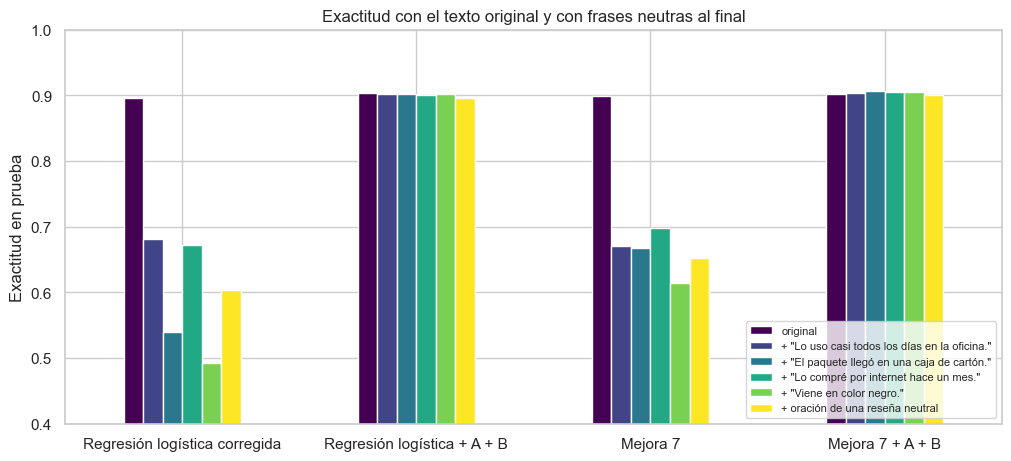

In [12]:
modelo_lr_robusta = ConAumento(Pipeline([('rep', construir_representacion_opinion()),
                                         ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                                       random_state=RANDOM_STATE))]))
modelo_m7_robusto = ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1))
modelo_lr_robusta.fit(X_train, y_train)
modelo_m7_robusto.fit(X_train, y_train)

despues = pd.DataFrame({'Regresión logística + A + B': exactitud_por_version(modelo_lr_robusta, versiones_test, y_test),
                        'Mejora 7 + A + B': exactitud_por_version(modelo_m7_robusto, versiones_test, y_test)})
tabla_test = pd.concat([antes, despues], axis=1)[['Regresión logística corregida', 'Regresión logística + A + B',
                                                  'Mejora 7', 'Mejora 7 + A + B']]
display(tabla_test.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
tabla_test.T.plot(kind='bar', ax=ax, legend=False, colormap='viridis')
ax.set(ylabel='Exactitud en prueba', ylim=(0.4, 1), title='Exactitud con el texto original y con frases neutras al final')
ax.legend(loc='lower right', fontsize=8)
plt.xticks(rotation=0)
plt.show()

Los arreglos cumplen su objetivo en el conjunto de prueba:

- **Robustez:** con una frase neutra al final, la regresión logística + A + B queda entre 0,8954 y 0,9025, y la Mejora 7 + A + B entre 0,9000 y 0,9067. La mayor caída frente al texto original es de 0,8 puntos, contra 20 a 40 puntos sin los arreglos.
- **Exactitud normal:** con el texto original los dos modelos también mejoran. La regresión logística pasa de 0,8954 a 0,9033 y la Mejora 7 de 0,8988 a 0,9025.

Algunas versiones con frase neutra quedan un poco por encima del texto original, por ejemplo 0,9067 contra 0,9025 en la Mejora 7 + A + B. Son 10 reseñas de 2.400 y no significa que la frase ayude: es la variación normal en una sola partición. Por la misma razón, la diferencia entre los dos modelos arreglados en esta partición (0,9033 contra 0,9025, 2 reseñas) no permite decir cuál es mejor. Para eso está la comparación de la sección 7.

## 7. Comparación con 15 particiones

Para saber si los arreglos cambian la exactitud normal de forma real, se usa la comparación de 15 particiones de siempre (3 repeticiones de validación cruzada de 5 particiones sobre las 12.000 reseñas). Para la regresión logística, que es rápida, se mide el efecto de cada arreglo por separado (A, B y A + B). Para el modelo de la Mejora 7, que tarda varios minutos por ajuste, solo la combinación A + B. La regla es la misma: una diferencia cuenta como mejora si supera 2 errores estándar y gana en al menos 12 de las 15 particiones.

In [13]:
particiones = []
for semilla in [1, 2, 3]:
    particiones += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X, y))


def lr_con(rep):
    return Pipeline([('rep', rep), ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                                 random_state=RANDOM_STATE))])


candidatos = {
    'Regresión logística corregida': lr_con(construir_representacion_corregida()),
    'Regresión logística + A': ConAumento(lr_con(construir_representacion_corregida())),
    'Regresión logística + B': lr_con(construir_representacion_opinion()),
    'Regresión logística + A + B': ConAumento(lr_con(construir_representacion_opinion())),
    'Mejora 7': ModeloDosEtapasNBLR(C_etapa2=0.1),
    'Mejora 7 + A + B': ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1)),
}
exactitudes = {nombre: cross_val_score(modelo, X, y, cv=particiones, scoring='accuracy', n_jobs=-1)
               for nombre, modelo in candidatos.items()}


def comparar(nombre, referencia):
    d = exactitudes[nombre] - exactitudes[referencia]
    ee = d.std(ddof=1) / np.sqrt(len(d))
    gana = int((d > 0).sum())
    veredicto = 'MEJORA' if d.mean() > 2 * ee and gana >= 12 else ('empeora' if d.mean() < -2 * ee and gana <= 3 else 'empate')
    return {'Modelo': nombre, 'Referencia': referencia, 'Exactitud media': exactitudes[nombre].mean(),
            'Diferencia': d.mean(), 'Error estándar': ee, 'Gana en (de 15)': gana, 'Veredicto': veredicto}


filas = [comparar('Regresión logística + A', 'Regresión logística corregida'),
         comparar('Regresión logística + B', 'Regresión logística corregida'),
         comparar('Regresión logística + A + B', 'Regresión logística corregida'),
         comparar('Mejora 7 + A + B', 'Mejora 7'),
         comparar('Regresión logística + A + B', 'Mejora 7'),
         comparar('Mejora 7 + A + B', 'Regresión logística + A + B')]
display(pd.DataFrame({n: v.mean() for n, v in exactitudes.items()}, index=['Exactitud media (15 particiones)']).T.round(4))
pd.DataFrame(filas).set_index(['Modelo', 'Referencia']).round(4)

,Exactitud media (15 particiones)
Regresión logística corregida,0.8988
Regresión logística + A,0.8977
Regresión logística + B,0.9033
Regresión logística + A + B,0.9046
Mejora 7,0.9023
Mejora 7 + A + B,0.9081


,,Exactitud media,Diferencia,Error estándar,Gana en (de 15),Veredicto
Modelo,Referencia,,,,,
Regresión logística + A,Regresión logística corregida,0.8977,-0.0010,0.0011,7,empate
Regresión logística + B,Regresión logística corregida,0.9033,0.0046,0.0010,11,empate
Regresión logística + A + B,Regresión logística corregida,0.9046,0.0058,0.0011,14,MEJORA
Mejora 7 + A + B,Mejora 7,0.9081,0.0059,0.0008,14,MEJORA
Regresión logística + A + B,Mejora 7,0.9046,0.0023,0.0009,11,empate
Mejora 7 + A + B,Regresión logística + A + B,0.9081,0.0036,0.0009,13,MEJORA


Los controles reproducen las cifras de los notebooks anteriores (0,8988 para la regresión logística corregida y 0,9023 para la Mejora 7), así que la comparación usa los mismos datos y particiones.

- **A solo no mejora la exactitud** (−0,10 puntos, gana en 7 de 15, empate). Era lo esperado: con el texto original, el aumento de datos no agrega información nueva; su objetivo es la robustez.
- **B solo sube 0,46 puntos**, pero gana en 11 de 15, una partición menos que el mínimo de la regla, así que cuenta como empate.
- **A + B en la regresión logística es una mejora:** +0,58 puntos, gana en 14 de 15 y la diferencia es de unos 5 errores estándar. La combinación supera a cada arreglo por separado.
- **A + B en la Mejora 7 también es una mejora:** +0,59 puntos (de 0,9023 a 0,9081), gana en 14 de 15 y la diferencia es de unos 7 errores estándar. Con 0,9081 es la mayor exactitud de todos los modelos del proyecto.
- **La regresión logística + A + B empata con la Mejora 7 sin arreglos** (+0,23 puntos, gana en 11 de 15). Con los arreglos, un modelo simple alcanza al modelo en dos etapas original.
- **La Mejora 7 + A + B supera a la regresión logística + A + B** (+0,36 puntos, gana en 13 de 15). Esta es la conclusión más frágil de la tabla. Gana en 13 de 15, apenas por encima del mínimo de 12, y las dos exactitudes dependen del sorteo del aumento de datos: qué reseñas se modifican y qué oraciones se agregan. Aquí se usa la misma semilla (0) en todas las particiones; con otra semilla la diferencia podría quedar en empate.

## 8. Modelos finales y predicciones para la competencia

Los dos modelos con los arreglos se entrenan con las 12.000 reseñas etiquetadas y generan sus envíos:

- `dos_etapas_nblr_robusto`: Mejora 7 + A + B.
- `regresion_logistica_robusta`: regresión logística por bloques + A + B.

In [14]:
finales = {
    'dos_etapas_nblr_robusto': ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1)),
    'regresion_logistica_robusta': ConAumento(lr_con(construir_representacion_opinion())),
}
envios = {}
for nombre, modelo in finales.items():
    modelo.fit(X, y)
    pred = modelo.predict(evaluacion[['text']])
    envios[nombre] = pd.DataFrame({'id': evaluacion['id'], 'answer': pred})
    envios[nombre].to_csv(os.path.join(RUTA_ENVIOS, f'submission_{nombre}.csv'), index=False)
    joblib.dump(modelo, os.path.join(RUTA_MODELOS, f'{nombre}.joblib'))
    cargado = joblib.load(os.path.join(RUTA_MODELOS, f'{nombre}.joblib'))
    print(f'{nombre}: formato correcto = {list(envios[nombre].columns) == list(muestra_envio.columns) and (envios[nombre]["id"] == muestra_envio["id"]).all()}'
          f' | el modelo guardado reproduce las predicciones = {(cargado.predict(evaluacion[["text"]]) == pred).all()}')

display(pd.DataFrame({'train (real)': y.value_counts(normalize=True),
                      **{f'eval ({n})': e['answer'].value_counts(normalize=True) for n, e in envios.items()}}).reindex(ORDEN_CLASES).round(3))

dos_etapas_nblr_robusto: formato correcto = True | el modelo guardado reproduce las predicciones = True


regresion_logistica_robusta: formato correcto = True | el modelo guardado reproduce las predicciones = True


,train (real),eval (dos_etapas_nblr_robusto),eval (regresion_logistica_robusta)
negativo,0.351,0.359,0.358
neutral,0.298,0.275,0.276
positivo,0.351,0.366,0.366


In [15]:
otros = {'Mejora 7 (dos_etapas_nblr)': 'submission_dos_etapas_nblr.csv',
         'Modelo actual (regresion_logistica_bloques)': 'submission_regresion_logistica_bloques.csv'}
filas = {}
for nombre, envio in envios.items():
    filas[nombre] = {o: int((pd.read_csv(os.path.join(RUTA_ENVIOS, archivo))['answer'].values != envio['answer'].values).sum())
                     for o, archivo in otros.items()}
    filas[nombre]['entre los dos modelos nuevos'] = int((envios['dos_etapas_nblr_robusto']['answer'].values !=
                                                         envios['regresion_logistica_robusta']['answer'].values).sum())
pd.DataFrame(filas).T

,Mejora 7 (dos_etapas_nblr),Modelo actual (regresion_logistica_bloques),entre los dos modelos nuevos
dos_etapas_nblr_robusto,113,191,102
regresion_logistica_robusta,169,157,102


Los dos envíos tienen el formato de `sample_submission.csv`, y los modelos guardados reproducen exactamente las predicciones. Las proporciones de clases predichas en `eval.csv` son casi iguales a las del envío de la Mejora 7 (27,7% `neutral`, 36,2% `negativo` y 36,1% `positivo`), así que los arreglos no introducen un sesgo hacia alguna clase.

Los cambios frente a los envíos anteriores son pocos:

- `dos_etapas_nblr_robusto` cambia 113 de las 3.000 predicciones (3,8%) frente al envío de la Mejora 7.
- `regresion_logistica_robusta` cambia 157 (5,2%) frente al envío del notebook principal.
- Los dos modelos nuevos difieren entre sí en 102 predicciones.

**Qué esperar en Kaggle.** La mejora esperada de la Mejora 7 + A + B sobre la Mejora 7 es de 0,59 puntos, unas 5 reseñas de las 900 del puntaje público. El ruido del puntaje público es de alrededor de ±1 punto (unas 9 reseñas), así que puede que no se note o incluso que el puntaje público baje un poco. La evidencia confiable es la comparación de 15 particiones. Ninguna decisión de este notebook se tomó con `eval.csv`: solo se usa para generar las predicciones.

**Resultado en Kaggle.** `dos_etapas_nblr_robusto` obtuvo 0,91777 (826/900) y `regresion_logistica_robusta` 0,91666 (825/900), frente a 0,90777 (817/900) de la Mejora 7. Según la comparación de 15 particiones se esperaban unos 817 y 814 aciertos, así que los dos quedaron cerca de 1 error estándar por encima. Como sus envíos coinciden en 2.898 de las 3.000 predicciones, comparten casi toda esa suerte. Para el puntaje final se espera algo cercano a la exactitud de 15 particiones.

## 9. Conclusiones

- **La debilidad se confirma.** Los dos modelos pierden entre 20 y 40 puntos de exactitud cuando se agrega una frase sin opinión al final de la reseña, también con oraciones de reseñas neutrales reales que no vieron al entrenarse.
- **Los dos arreglos la corrigen.** Con aumento de datos (A) y la última oración con opinión (B), la exactitud se mantiene cerca de 0,90 con cualquiera de las frases neutras.
- **Además mejoran la exactitud normal.** La Mejora 7 + A + B llega a 0,9081 en 15 particiones (+0,59 puntos, gana en 14 de 15), la mejor del proyecto. La regresión logística + A + B sube a 0,9046 (+0,58) y empata con la Mejora 7 original.
- **La mejora viene de combinar los dos arreglos.** A por sí solo no cambia la exactitud y B por sí solo queda justo por debajo del umbral de la regla. Juntos superan a cada uno por separado.
- **Modelo recomendado:** `dos_etapas_nblr_robusto` (Mejora 7 + A + B). Es el más exacto, el más robusto y tiene el mejor puntaje público del grupo (0,91777). `regresion_logistica_robusta` es una alternativa más simple y rápida con una exactitud cercana. La ventaja de la Mejora 7 + A + B sobre ella (13 de 15) es la conclusión menos segura.

**Limitaciones.**

- El detector se entrena con una aproximación: toma como "hecho" todas las oraciones de reseñas neutrales y como "opinión" la cláusula final de las demás. Solo reconoce opiniones explícitas y podría saltar quejas implícitas.
- La robustez solo se midió con frases agregadas al final. Las reseñas reales podrían tener otros cambios, como frases neutras en medio del texto, preguntas o errores de digitación (el diagnóstico encontró que estos últimos bajan la exactitud cerca de 1 punto).
- El puntaje público (0,91777) probablemente sobreestima la exactitud real. La estimación más confiable es la de 15 particiones (0,9081).

## 10. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Opus 5.5, de Anthropic) como apoyo para: proponer los dos arreglos, probarlos en experimentos previos, generar un primer esqueleto del código de este notebook y redactar las explicaciones.

**Prompts utilizados.**

1. *"si, prueba los dos arreglos"*, después de que el notebook de diagnóstico encontrara la debilidad ante frases neutras al final y propusiera dos posibles arreglos.
2. *"si, arma la mejora 9"*.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 11. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/` y los envíos en `submissions/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). Tarda alrededor de 35 minutos en un computador de 8 núcleos, sobre todo por la comparación de 15 particiones y el entrenamiento final del modelo en dos etapas.
4. Al terminar se generan `models/dos_etapas_nblr_robusto.joblib`, `models/regresion_logistica_robusta.joblib` y sus envíos en `submissions/`.

Todas las fuentes de aleatoriedad usan semillas fijas, por lo que las cifras se reproducen exactamente con las versiones de `requirements.txt`. Para cargar los modelos guardados fuera del notebook hay que ejecutar antes las celdas que definen las funciones y las clases de las secciones 3 y 5.